In [3]:
import numpy as np


def read_latency_data(file, ignore):
    data = {"end_to_end": [], "service": [], "slo": []}
    with open(file, "r") as file:
        for line in file.readlines():
            span, slo, latency = line.strip().split(",")
            assert span in data.keys()
            data[span].append(int(latency))
            if span == "end_to_end":
                data["slo"].append(int(slo))
    for key in data.keys():
        n_ignore = int(len(data[key]) * ignore)
        data[key] = data[key][n_ignore:]
    return data


def get_pctl(data, pctl):
    data = np.sort(data)
    tail = np.percentile(data, pctl).astype(int)
    return tail


def get_slo_vio(data, slo):
    cnt = 0
    for i in range(len(data)):
        if data[i] > slo[i]:
            cnt += 1
    return cnt / len(data) * 100

In [12]:
rps_values = list(range(100, 2001, 100))
e2e_data = {
    "rps": [],
    "fcfs": [],
    "masa": [],
}


pctl = 99
for rps in rps_values:
    e2e_data["rps"].append(rps)

    file = f"r{rps}-fcfs.csv"
    data = read_latency_data(file, ignore=0.01)
    e2e_data["fcfs"].append(get_slo_vio(data["end_to_end"], data["slo"]))

    file = f"r{rps}-masa.csv"
    data = read_latency_data(file, ignore=0.01)
    e2e_data["masa"].append(get_slo_vio(data["end_to_end"], data["slo"]))

print(e2e_data)
print()

{'rps': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000], 'fcfs': [0.05056463846283499, 0.0513083632632119, 0.17347509792949078, 0.2748414376321353, 0.5221668238781835, 1.392394530274873, 2.0240079221312466, 3.9573022397449877, 6.3585764884466185, 10.372057706909644, 16.175440733185155, 23.32763485246494, 30.57558622120772, 38.567453463826524, 45.109565879494326, 48.58347580738208, 49.711359128452585, 50.106280374181836, 56.47163435888316, 77.07029138403055], 'masa': [0.06741951795044665, 0.034205575508807935, 0.106323447118075, 0.1057037757388694, 0.22907963886268698, 0.3855435053948354, 0.598990411322851, 0.801107289656908, 1.2837090759168681, 1.896598272138229, 2.792028864158814, 4.10846571877302, 5.888303805348759, 8.442477451544809, 12.70351376167335, 18.17285504510174, 23.463295736009552, 31.240811663685825, 91.91294142750453, 99.21528964531092]}



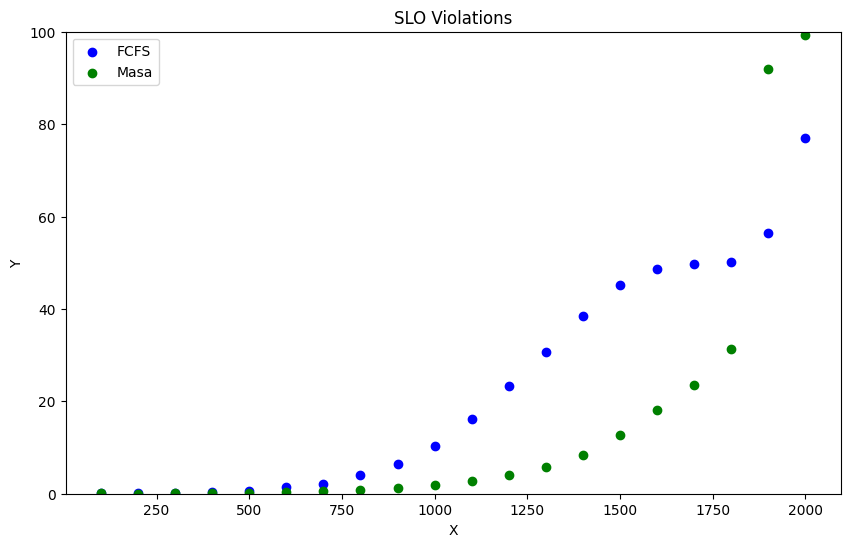

slo: 1, FCFS: 555, Masa: 841
slo: 5, FCFS: 843, Masa: 1250
slo: 10, FCFS: 991, Masa: 1437


In [22]:
import numpy as np
import matplotlib.pyplot as plt


def solve(x, y, slo):
    # x and y are x and y values
    # slo is the SLO value
    # returns the x value where y is less than slo
    # I want an estimation of the x value rather than discrete value
    # so between two consecutive (x, y) values, imagine a line
    # and find the intersection of that line with the slo if there is any

    # Ensure the input lists are of equal length and are not empty
    if len(x) != len(y) or len(x) == 0:
        return None

    # Traverse the list to find the point where y crosses below slo
    for i in range(1, len(y)):
        if y[i - 1] <= slo and y[i] > slo:
            # Linear interpolation
            # Equation of line (y - y1) = ((y2 - y1) / (x2 - x1)) * (x - x1)
            # Solving for x when y = slo:
            # x = x1 + ((slo - y1) / (y2 - y1)) * (x2 - x1)
            if y[i] != y[i - 1]:  # to avoid division by zero
                x_interpolated = x[i - 1] + ((slo - y[i - 1]) / (y[i] - y[i - 1])) * (
                    x[i] - x[i - 1]
                )
                return x_interpolated

    # If no crossing is found or all y-values are below slo
    return None


data = e2e_data
x = np.array(data["rps"])
y1 = np.array(data["fcfs"])
y2 = np.array(data["masa"])

plt.figure(figsize=(10, 6))
plt.scatter(x, y1, color="blue", label="FCFS")
plt.scatter(x, y2, color="green", label="Masa")

plt.title("SLO Violations")
plt.xlabel("X")
plt.ylabel("Y")
plt.ylim(0, 100)
plt.legend()
plt.show()

for slo in [1, 5, 10]:
    x1 = round(solve(x, y1, slo))
    x2 = round(solve(x, y2, slo))
    print(f"slo: {slo}, FCFS: {x1}, Masa: {x2}")